In [1]:
import pandas as pd
import seaborn as sns

# Cargamos los datos desde un archivo CSV
data_gas = pd.read_csv('database_gas.csv')
data_pos = pd.read_csv('database_pos.csv')
print(data_gas.info())
print(data_pos.info())

# Mostramos las primeras filas de cada DataFrame para verificar la carga correcta   
print("Datos de gas:")
print(data_gas.head())
print("\nDatos de posición:")
print(data_pos.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416153 entries, 0 to 416152
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   timestamp      416153 non-null  object 
 1   temperature    416153 non-null  float64
 2   humidity       416153 non-null  float64
 3   CO2CosIRValue  416153 non-null  float64
 4   CO2MG811Value  416153 non-null  float64
 5   MOX1           416153 non-null  float64
 6   MOX2           416153 non-null  float64
 7   MOX3           416153 non-null  float64
 8   MOX4           416153 non-null  float64
 9   COValue        416153 non-null  float64
dtypes: float64(9), object(1)
memory usage: 31.8+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28478 entries, 0 to 28477
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     28478 non-null  object 
 1   Living room  8866 non-null   float64
 2   Bedroom   

In [69]:
data_gas['timestamp'] = pd.to_datetime(data_gas['timestamp'])
data_pos['datetime'] = pd.to_datetime(data_pos['datetime'])
data_pos['tiempo_redondeado'] = data_pos['datetime'].dt.round('1min')
data_gas['tiempo_redondeado'] = data_gas['timestamp'].dt.round('1min')
data_pos.drop(columns=['datetime']  , inplace=True)
data_gas.drop(columns=['timestamp']  , inplace=True)


In [70]:
print(data_gas.head())
print(data_pos.head())  
print(data_gas.shape)
print(data_pos.shape)


   temperature  humidity  CO2CosIRValue  CO2MG811Value   MOX1   MOX2   MOX3  \
0        19.48     54.86          128.0          563.0  476.0  731.0  649.0   
1        19.59     54.23          129.0          563.0  477.0  731.0  649.0   
2        19.63     54.05          128.0          566.0  478.0  732.0  649.0   
3        19.64     53.74          128.0          566.0  478.0  732.0  649.0   
4        19.67     53.53          128.0          569.0  480.0  732.0  650.0   

    MOX4  COValue         tiempo_redondeado  
0  565.0    128.0 2019-11-06 11:37:00+01:00  
1  565.0    125.0 2019-11-06 11:38:00+01:00  
2  565.0    125.0 2019-11-06 11:38:00+01:00  
3  565.0    125.0 2019-11-06 11:38:00+01:00  
4  565.0    125.0 2019-11-06 11:39:00+01:00  
   Living room  Bedroom  Bathroom  Kitchen  Hallway         tiempo_redondeado
0          NaN      0.0       NaN      NaN      NaN 2019-11-01 02:53:00+00:00
1          NaN      1.0       NaN      NaN      NaN 2019-11-01 03:20:00+00:00
2          NaN 

In [71]:
# Borramos los tiempos duplicados en data_gas y data_pos
data_gas = data_gas.drop_duplicates(subset=['tiempo_redondeado'], keep='first')
data_pos = data_pos.drop_duplicates(subset=['tiempo_redondeado'], keep='first')
print(data_gas.shape)
print(data_pos.shape)

(138732, 10)
(15389, 6)


In [72]:
# Realizamos un merge de los dos DataFrames basado en una columna tiempo redondeado
df = pd.merge(data_gas, data_pos, on='tiempo_redondeado',how='inner')


In [73]:
print(df.shape)
# Nos encanta el resultado

(14544, 15)


In [74]:
df.fillna(0, inplace=True)


lista_columnas = ['Living room', 'Bedroom', 'Kitchen', 'Bathroom', 'Hallway']

# axis=1 indica que la suma es horizontal (por fila)
df["Home"] = df[lista_columnas].sum(axis=1)
df.head()
# Hacemos un histograma de la nueva columna


,temperature,humidity,CO2CosIRValue,CO2MG811Value,MOX1,MOX2,MOX3,MOX4,COValue,tiempo_redondeado,Living room,Bedroom,Bathroom,Kitchen,Hallway,Home
0,19.48,54.86,128.0,563.0,476.0,731.0,649.0,565.0,128.0,2019-11-06 11:37:00+01:00,0.0,0.0,0.0,0.0,0.0,0.0
1,19.66,53.51,127.0,574.0,489.0,732.0,650.0,566.0,118.0,2019-11-06 11:42:00+01:00,0.0,0.0,1.0,0.0,0.0,1.0
2,19.77,53.82,128.0,576.0,494.0,732.0,650.0,566.0,117.0,2019-11-06 11:43:00+01:00,0.0,0.0,0.0,0.0,1.0,1.0
3,19.66,53.82,128.0,578.0,496.0,732.0,650.0,566.0,116.0,2019-11-06 11:44:00+01:00,1.0,0.0,0.0,0.0,0.0,1.0
4,19.60,53.87,128.0,579.0,496.0,732.0,650.0,565.0,114.0,2019-11-06 11:45:00+01:00,0.0,0.0,0.0,0.0,0.0,0.0


In [75]:
df['not_home'] = (df['Home'] == 0).astype(int)
df['Living room'] = df['Living room'].astype(int)
df['Bedroom'] = df['Bedroom'].astype(int)
df['Kitchen'] = df['Kitchen'].astype(int)
df['Bathroom'] = df['Bathroom'].astype(int)
df['Hallway'] = df['Hallway'].astype(int)
df.head()

,temperature,humidity,CO2CosIRValue,CO2MG811Value,MOX1,MOX2,MOX3,MOX4,COValue,tiempo_redondeado,Living room,Bedroom,Bathroom,Kitchen,Hallway,Home,not_home
0,19.48,54.86,128.0,563.0,476.0,731.0,649.0,565.0,128.0,2019-11-06 11:37:00+01:00,0,0,0,0,0,0.0,1
1,19.66,53.51,127.0,574.0,489.0,732.0,650.0,566.0,118.0,2019-11-06 11:42:00+01:00,0,0,1,0,0,1.0,0
2,19.77,53.82,128.0,576.0,494.0,732.0,650.0,566.0,117.0,2019-11-06 11:43:00+01:00,0,0,0,0,1,1.0,0
3,19.66,53.82,128.0,578.0,496.0,732.0,650.0,566.0,116.0,2019-11-06 11:44:00+01:00,1,0,0,0,0,1.0,0
4,19.60,53.87,128.0,579.0,496.0,732.0,650.0,565.0,114.0,2019-11-06 11:45:00+01:00,0,0,0,0,0,0.0,1


<Axes: xlabel='Home', ylabel='count'>

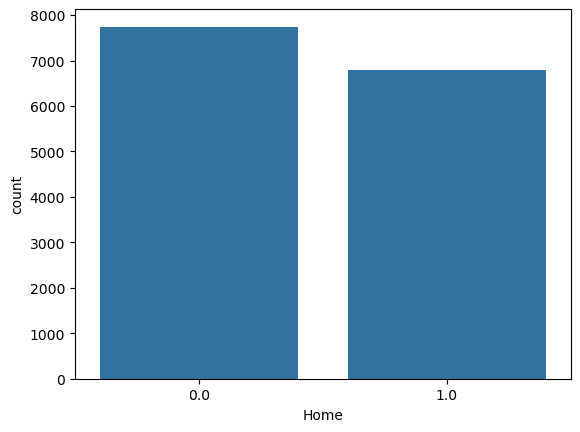

In [76]:
sns.countplot(data=df, x="Home")

In [77]:
subconjunto = df[['Living room', 'Bedroom', 'Kitchen', 'Bathroom', 'Hallway']]
df_categorico = pd.from_dummies(subconjunto, default_category = 'not_home' )
df_categorico.head()

,
0,not_home
1,Bathroom
2,Hallway
3,Living room
4,not_home


In [78]:
df["position"] = df_categorico
df.head()

,temperature,humidity,CO2CosIRValue,CO2MG811Value,MOX1,MOX2,MOX3,MOX4,COValue,tiempo_redondeado,Living room,Bedroom,Bathroom,Kitchen,Hallway,Home,not_home,position
0,19.48,54.86,128.0,563.0,476.0,731.0,649.0,565.0,128.0,2019-11-06 11:37:00+01:00,0,0,0,0,0,0.0,1,not_home
1,19.66,53.51,127.0,574.0,489.0,732.0,650.0,566.0,118.0,2019-11-06 11:42:00+01:00,0,0,1,0,0,1.0,0,Bathroom
2,19.77,53.82,128.0,576.0,494.0,732.0,650.0,566.0,117.0,2019-11-06 11:43:00+01:00,0,0,0,0,1,1.0,0,Hallway
3,19.66,53.82,128.0,578.0,496.0,732.0,650.0,566.0,116.0,2019-11-06 11:44:00+01:00,1,0,0,0,0,1.0,0,Living room
4,19.60,53.87,128.0,579.0,496.0,732.0,650.0,565.0,114.0,2019-11-06 11:45:00+01:00,0,0,0,0,0,0.0,1,not_home


In [79]:
lista_columnas = ['Living room', 'Bedroom', 'Kitchen', 'Bathroom', 'Hallway', 'not_home']
df.drop(columns=lista_columnas, inplace=True)

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14544 entries, 0 to 14543
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype                    
---  ------             --------------  -----                    
 0   temperature        14544 non-null  float64                  
 1   humidity           14544 non-null  float64                  
 2   CO2CosIRValue      14544 non-null  float64                  
 3   CO2MG811Value      14544 non-null  float64                  
 4   MOX1               14544 non-null  float64                  
 5   MOX2               14544 non-null  float64                  
 6   MOX3               14544 non-null  float64                  
 7   MOX4               14544 non-null  float64                  
 8   COValue            14544 non-null  float64                  
 9   tiempo_redondeado  14544 non-null  datetime64[ns, UTC+01:00]
 10  Home               14544 non-null  float64                  
 11  position           14544 non

In [81]:
# Hacemos particion de los datos para entrenamiento y prueba
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=314159)

In [82]:
# Exportamos los datos a CSV para usarlos en otros scripts
train_df.to_csv('train_df.csv', index=False)
test_df.to_csv('test_df.csv', index=False)